# Informe 4: Modelos de Clasificación

- **Asignatura:** Inteligencia Artificial
- **Grupo:** 03
- **Integrantes:** Bautista De la Cruz Claudia Daniela, Carrascal Castro Priscila Maria, Ccahuana Quiñones Judith Valeria, Gil Sixi Alberto Luis, Medrano Ayma Nikol Arlet, Rosales Trinidad Jeanmarco Miguel, Saire Tello Fernando José

## Empresa: AndinaSense

AndinaSense es una empresa de agricultura de precisión que brinda servicios de monitoreo a agroexportadoras de arándano en los valles de la costa norte del Perú (La Libertad, Lambayeque e Ica). Mediante sensores instalados en las parcelas, registra las condiciones de suelo, clima y manejo de cada una. Con miles de parcelas bajo monitoreo, necesita agruparlas en perfiles que permitan un manejo diferenciado y eficiente, en lugar de tratarlas todas por igual.

**Objetivo del informe:** Clasificar la calidad de la cosecha de una parcela de
arándano (`calidad_cosecha`: Baja, Media o Alta) a partir de sus condiciones de
suelo, clima y manejo, usando modelos de clasificación supervisada.

**Pregunta de negocio:** ¿Qué calidad tendrá la cosecha de una parcela según sus
condiciones medidas por los sensores?

**Por qué aporta valor:** Anticipar la calidad permite a AndinaSense priorizar
parcelas, ajustar el manejo (pH, riego, fertilización) e intervenir a tiempo en las
parcelas con riesgo de calidad Baja, antes de que el problema se refleje en la
cosecha.

## Generación y carga del dataset

El dataset `andinasense_parcelas.csv` es sintético y propio del grupo. Contiene 1500 parcelas (filas) y 13 variables (columnas), con mezcla de numéricas y categóricas. La variable objetivo continua es `rendimiento_kg_ha` y la categórica es `calidad_cosecha` (Baja, Media, Alta).

Generación (reproducible con semilla SEED = 42):

- Las parcelas provienen de 4 zonas agroecológicas latentes con proporciones controladas (Óptima 35%, Estrés Hídrico 25%, Desbalance de pH 20%, Multi-estrés Leve 20%). La zona se usa solo para generar y no aparece como columna.
- Cada zona tiene un perfil de medias por variable de suelo, clima y manejo, con dispersión calibrada para un solapamiento realista (correlaciones y ruido, no grupos perfectos).
- `rendimiento_kg_ha` se deriva de una función de respuesta agronómica con penalización cuadrática (óptimo de temperatura 20 °C y de pH 5.5) más ruido gaussiano; `calidad_cosecha` se obtiene por terciles del rendimiento.
- Se introdujeron nulos y valores atípicos intencionales en las columnas de sensores para exigir tratamiento en el preprocesamiento.

El script generador completo, reproducible con la misma semilla, está en el repositorio del proyecto (carpeta `generador_dataset`). Este notebook no regenera los datos: solo carga el CSV en la siguiente celda.

## 1. Configuración e Importación de Librerías

In [1]:
# ── Celda 1: Importaciones ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)
from scipy.stats import randint, uniform

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
sns.set_style('whitegrid')

SEED = 42
np.random.seed(SEED)
print('Librerías importadas correctamente.')
print(f'Versión scikit-learn: {__import__("sklearn").__version__}')

Librerías importadas correctamente.
Versión scikit-learn: 1.4.2


## 2. Carga y Análisis Exploratorio de Datos (EDA)

Se carga el dataset `andinasense_parcelas.csv` (1500 parcelas, 13 columnas) y se
exploran tipos, estadísticas, balance de la variable objetivo y correlaciones. El
dataset contiene valores faltantes en `humedad_suelo`, `ph_suelo` y `horas_sol`,
que se tratarán en el preprocesamiento.

In [2]:
# ── Celda 2a: Cargar el dataset ─────────────────────────────────────────
df = pd.read_csv('andinasense_parcelas.csv')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dimensiones: 1500 filas x 13 columnas


,id_parcela,region,variedad,superficie_ha,temp_promedio,humedad_suelo,ph_suelo,horas_sol,riego_mm,fertilizante_kg,densidad_plantas,rendimiento_kg_ha,calidad_cosecha
0,PARC-00001,Lambayeque,Emerald,10.55,19.5,55.5,6.72,9.6,523.0,282.0,4443.0,8476.0,Baja
1,PARC-00002,Lambayeque,Biloxi,4.33,22.0,42.1,5.48,8.4,698.0,166.0,4204.0,8542.0,Baja
2,PARC-00003,La Libertad,Ventura,5.04,21.0,40.7,6.22,7.7,619.0,253.0,3547.0,9270.0,Alta
3,PARC-00004,La Libertad,Rocio,7.19,20.4,52.1,6.63,9.2,507.0,277.0,4229.0,8624.0,Media
4,PARC-00005,Lambayeque,Biloxi,2.76,20.8,56.9,5.33,9.2,592.0,201.0,3778.0,9033.0,Media


In [3]:
# ── Celda 2b: Información general y tipos de datos ──────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_parcela         1500 non-null   object 
 1   region             1500 non-null   object 
 2   variedad           1500 non-null   object 
 3   superficie_ha      1500 non-null   float64
 4   temp_promedio      1500 non-null   float64
 5   humedad_suelo      1440 non-null   float64
 6   ph_suelo           1455 non-null   float64
 7   horas_sol          1463 non-null   float64
 8   riego_mm           1500 non-null   float64
 9   fertilizante_kg    1500 non-null   float64
 10  densidad_plantas   1500 non-null   float64
 11  rendimiento_kg_ha  1500 non-null   float64
 12  calidad_cosecha    1500 non-null   object 
dtypes: float64(9), object(4)
memory usage: 152.5+ KB


In [4]:
# ── Celda 2c: Estadísticas descriptivas ─────────────────────────────────
df.describe().round(2)

,superficie_ha,temp_promedio,humedad_suelo,ph_suelo,horas_sol,riego_mm,fertilizante_kg,densidad_plantas,rendimiento_kg_ha
count,1500.00,1500.00,1440.00,1455.00,1463.00,1500.00,1500.00,1500.00,1500.00
mean,7.03,21.19,52.31,5.95,8.75,600.58,219.99,3937.51,8795.93
std,2.94,1.42,10.51,0.65,0.90,73.16,39.60,349.17,523.58
min,2.00,17.60,25.30,4.72,5.80,442.00,106.00,2831.00,6740.00
25%,4.50,20.10,43.90,5.50,8.20,546.00,193.00,3695.00,8439.00
50%,7.04,21.10,53.60,5.73,8.90,586.00,218.00,3954.50,8832.00
75%,9.60,22.32,60.00,6.30,9.40,653.00,247.00,4184.25,9172.75
max,11.99,25.50,120.60,11.72,10.90,830.00,362.00,5059.00,10131.00


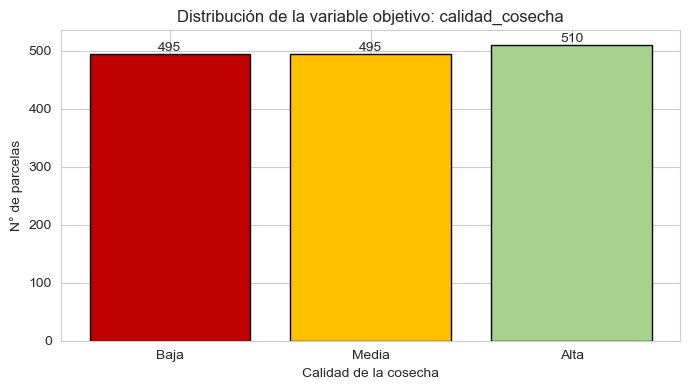

Proporción por clase:
calidad_cosecha
Baja     0.33
Media    0.33
Alta     0.34
Name: proportion, dtype: float64

Las clases están prácticamente equilibradas (Baja ≈ 33%, Media ≈ 33%,
Alta ≈ 34%): aun así se prioriza el F1-Score (weighted), que se mantendría
informativo si el balance cambiara en datos reales.


In [5]:
# ── Celda 2d: Distribución de la variable objetivo (calidad_cosecha) ────
orden = ['Baja', 'Media', 'Alta']
conteo = df['calidad_cosecha'].value_counts().reindex(orden)
prop = df['calidad_cosecha'].value_counts(normalize=True).reindex(orden).round(3)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(conteo.index, conteo.values, edgecolor='black',
              color=['#C00000', '#FFC000', '#A9D18E'])
ax.set_title('Distribución de la variable objetivo: calidad_cosecha')
ax.set_xlabel('Calidad de la cosecha'); ax.set_ylabel('N° de parcelas')
for b, v in zip(bars, conteo.values):
    ax.text(b.get_x() + b.get_width()/2, v + 5, str(v), ha='center', fontsize=10)
plt.tight_layout(); plt.savefig('eda_calidad.png', dpi=120, bbox_inches='tight'); plt.show()

print('Proporción por clase:'); print(prop)
print('\nLas clases están prácticamente equilibradas (Baja ≈ 33%, Media ≈ 33%,')
print('Alta ≈ 34%): aun así se prioriza el F1-Score (weighted), que se mantendría')
print('informativo si el balance cambiara en datos reales.')

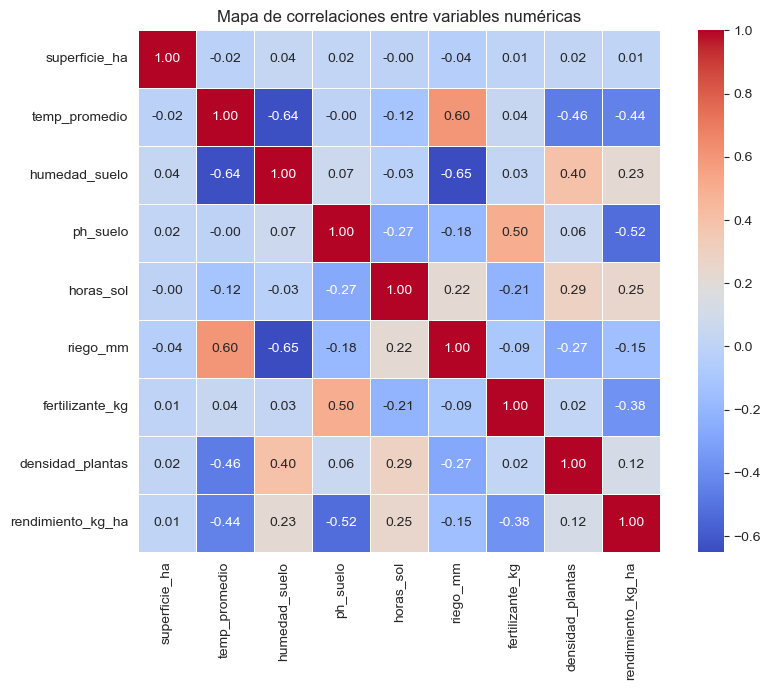

In [6]:
# ── Celda 2e: Mapa de calor de correlaciones (variables numéricas) ──────
num_cols_eda = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols_eda].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            linewidths=0.5, linecolor='white')
plt.title('Mapa de correlaciones entre variables numéricas')
plt.tight_layout(); plt.savefig('eda_correlaciones.png', dpi=120, bbox_inches='tight'); plt.show()

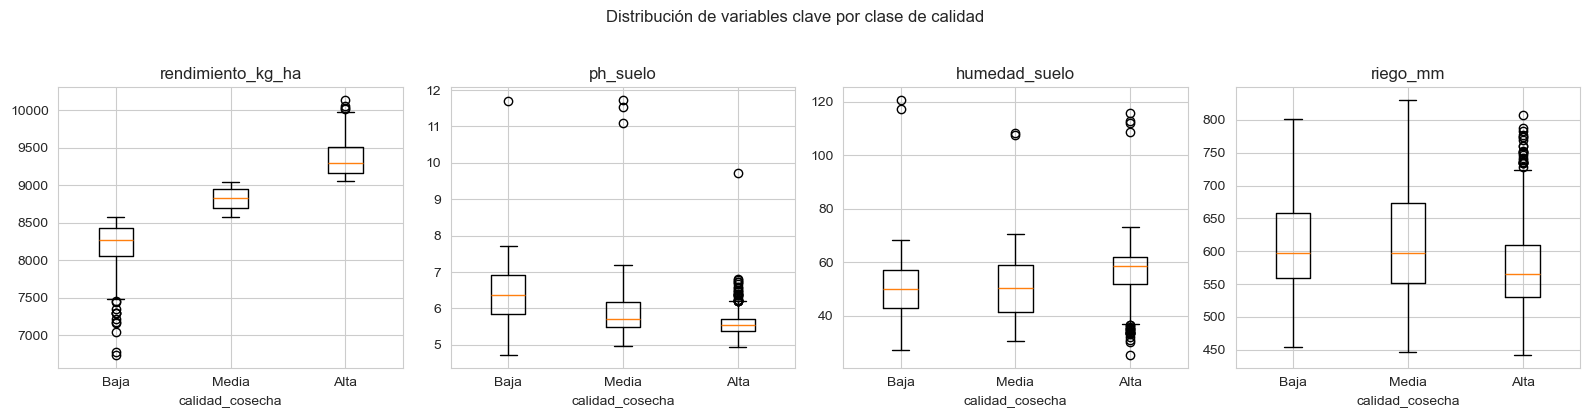

In [7]:
# ── Celda 2f: Variables clave según la calidad de cosecha ───────────────
variables = ['rendimiento_kg_ha', 'ph_suelo', 'humedad_suelo', 'riego_mm']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, var in zip(axes, variables):
    datos = [df.loc[df['calidad_cosecha'] == c, var].dropna() for c in orden]
    ax.boxplot(datos, labels=orden)
    ax.set_title(var); ax.set_xlabel('calidad_cosecha')
plt.suptitle('Distribución de variables clave por clase de calidad', y=1.03)
plt.tight_layout(); plt.savefig('eda_boxplots_clase.png', dpi=120, bbox_inches='tight'); plt.show()

### Observaciones del análisis exploratorio (EDA)

- Conocer el balance de clases es importante porque determina qué métrica es confiable. Si una clase dominara, un modelo podría alcanzar un accuracy alto simplemente prediciendo siempre la clase mayoritaria, sin haber aprendido nada útil.
- En este dataset las clases están prácticamente equilibradas: Baja ≈ 495 (33%), Media ≈ 495 (33%) y Alta ≈ 510 (34%), por lo que el accuracy y el F1-Score weighted dan valores muy parecidos.
- Aun así se usa el F1-Score como métrica principal, porque equilibra precisión y recall y se mantendría informativa si el balance cambiara en datos reales.
- Según los boxplots por clase, la variable que mejor separa las tres categorías es, con mucha diferencia, rendimiento_kg_ha: las cajas de Baja, Media y Alta casi no se solapan (a mayor rendimiento, mejor calidad).
- En segundo lugar aparecen ph_suelo y humedad_suelo, que ayudan a distinguir la calidad cuando están dentro o fuera del rango ideal.

## 3. Preprocesamiento de Datos

Se tratan los valores faltantes (imputación), se codifican las variables
categóricas y se escalan las numéricas dentro de un `Pipeline`, de modo que el
ajuste (`fit`) se calcule solo con los datos de entrenamiento y se evite la
fuga de información (*data leakage*).

In [8]:
# ── Celda 3a: Separar predictoras y objetivo ────────────────────────────
# 'id_parcela' es identificador, no predictor.
# La objetivo es 'calidad_cosecha'. 'rendimiento_kg_ha' SÍ se usa como predictora
# (a mayor rendimiento, mayor probabilidad de calidad alta).
df_mod = df.drop(columns=['id_parcela'])

X = df_mod.drop(columns=['calidad_cosecha'])
# Codificación ordinal de la clase para mantener el orden natural Baja < Media < Alta.
mapa_clases = {'Baja': 0, 'Media': 1, 'Alta': 2}
clases = ['Baja', 'Media', 'Alta']          # nombres para reportes y gráficos
y = df_mod['calidad_cosecha'].map(mapa_clases)

col_numericas = X.select_dtypes(include='number').columns.tolist()
col_categoricas = X.select_dtypes(exclude='number').columns.tolist()
print('Columnas numéricas:', col_numericas)
print('Columnas categóricas:', col_categoricas)
print('Mapeo de clases:', mapa_clases)

Columnas numéricas: ['superficie_ha', 'temp_promedio', 'humedad_suelo', 'ph_suelo', 'horas_sol', 'riego_mm', 'fertilizante_kg', 'densidad_plantas', 'rendimiento_kg_ha']
Columnas categóricas: ['region', 'variedad']
Mapeo de clases: {'Baja': 0, 'Media': 1, 'Alta': 2}


In [9]:
# ── Celda 3b: División entrenamiento / prueba (80/20, estratificada) ────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)
print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print('Proporción de clases en train:')
print(y_train.value_counts(normalize=True).round(3).sort_index())

X_train: (1200, 11) | X_test: (300, 11)
Proporción de clases en train:
calidad_cosecha
0    0.33
1    0.33
2    0.34
Name: proportion, dtype: float64


In [10]:
# ── Celda 3c: Pipeline de preprocesamiento ──────────────────────────────
# Numéricas: imputar nulos con la mediana + escalar.
# Categóricas (region, variedad): imputar con la moda + OneHotEncoder.
prep_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
prep_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', prep_num, col_numericas),
    ('cat', prep_cat, col_categoricas)
])
print('Pipeline de preprocesamiento definido correctamente.')

Pipeline de preprocesamiento definido correctamente.


## 4. Modelos de Clasificación

Se entrena una **Regresión Logística** como modelo de referencia (*baseline*) y se
compara con KNN, SVC, Naive Bayes, Árbol de Decisión, Random Forest (ensamble
*bagging*) y Gradient Boosting (*boosting*). Donde el modelo lo permite se usa
`class_weight='balanced'` para compensar el desbalance de clases.

In [11]:
# ── Celda 4a: Función de evaluación reutilizable ────────────────────────
resultados = []          # métricas de cada modelo (para la tabla comparativa)
modelos_fit = {}         # pipelines ya entrenados (para matriz de confusión, etc.)

def evaluar(nombre, pipe):
    """Entrena el pipeline, evalúa en test y guarda Accuracy/Precision/Recall/F1."""
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    fila = {
        'Modelo':    nombre,
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, average='weighted'),
        'Recall':    recall_score(y_test, pred, average='weighted'),
        'F1':        f1_score(y_test, pred, average='weighted'),
    }
    resultados.append(fila)
    modelos_fit[nombre] = pipe
    print(f"{nombre:<28} | Acc={fila['Accuracy']:.3f} | "
          f"Prec={fila['Precision']:.3f} | Rec={fila['Recall']:.3f} | F1={fila['F1']:.3f}")
    return pipe

In [12]:
# ── Celda 4b: Regresión Logística (multinomial) — BASELINE ──────────────
pipe_log = Pipeline([('pre', preprocessor),
                     ('clf', LogisticRegression(max_iter=1000,
                                                class_weight='balanced',
                                                random_state=SEED))])
evaluar('Reg. Logística', pipe_log)

Reg. Logística               | Acc=0.980 | Prec=0.980 | Rec=0.980 | F1=0.980


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['superficie_ha',
                                                   'temp_promedio',
                                                   'humedad_suelo', 'ph_suelo',
                                                   'horas_sol', 'riego_mm',
                                                   'fertilizante_kg',
                                                   'densidad_plantas',
                                                   'rendimiento_kg_ha']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['region', 'variedad'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [13]:
# ── Celda 4c: K-Nearest Neighbors (KNN) ─────────────────────────────────
pipe_knn = Pipeline([('pre', preprocessor),
                     ('clf', KNeighborsClassifier(n_neighbors=7, weights='distance'))])
evaluar('KNN (k=7)', pipe_knn)

KNN (k=7)                    | Acc=0.763 | Prec=0.769 | Rec=0.763 | F1=0.766


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['superficie_ha',
                                                   'temp_promedio',
                                                   'humedad_suelo', 'ph_suelo',
                                                   'horas_sol', 'riego_mm',
                                                   'fertilizante_kg',
                                                   'densidad_plantas',
                                                   'rendimiento_kg_ha']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['region', 'variedad'])])),
                ('clf',
                 KNeighborsClassifier(n_neighbors=7, weights='distance'))])

In [14]:
# ── Celda 4d: Support Vector Classifier (SVC) ───────────────────────────
pipe_svc = Pipeline([('pre', preprocessor),
                     ('clf', SVC(kernel='rbf', C=1.0,
                                 class_weight='balanced', random_state=SEED))])
evaluar('SVC (RBF)', pipe_svc)

SVC (RBF)                    | Acc=0.907 | Prec=0.907 | Rec=0.907 | F1=0.907


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['superficie_ha',
                                                   'temp_promedio',
                                                   'humedad_suelo', 'ph_suelo',
                                                   'horas_sol', 'riego_mm',
                                                   'fertilizante_kg',
                                                   'densidad_plantas',
                                                   'rendimiento_kg_ha']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['region', 'variedad'])])),
                ('clf', SVC(class_weight='balanced', random_state=42))])

In [15]:
# ── Celda 4e: Gaussian Naive Bayes ──────────────────────────────────────
pipe_nb = Pipeline([('pre', preprocessor),
                    ('clf', GaussianNB())])
evaluar('Naive Bayes', pipe_nb)

Naive Bayes                  | Acc=0.873 | Prec=0.872 | Rec=0.873 | F1=0.872


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['superficie_ha',
                                                   'temp_promedio',
                                                   'humedad_suelo', 'ph_suelo',
                                                   'horas_sol', 'riego_mm',
                                                   'fertilizante_kg',
                                                   'densidad_plantas',
                                                   'rendimiento_kg_ha']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['region', 'variedad'])])),
                ('clf', GaussianNB())])

In [16]:
# ── Celda 4f: Árbol de Decisión ─────────────────────────────────────────
pipe_tree = Pipeline([('pre', preprocessor),
                      ('clf', DecisionTreeClassifier(max_depth=6, min_samples_leaf=20,
                                                     class_weight='balanced',
                                                     random_state=SEED))])
evaluar('Árbol de Decisión', pipe_tree)

Árbol de Decisión            | Acc=1.000 | Prec=1.000 | Rec=1.000 | F1=1.000


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['superficie_ha',
                                                   'temp_promedio',
                                                   'humedad_suelo', 'ph_suelo',
                                                   'horas_sol', 'riego_mm',
                                                   'fertilizante_kg',
                                                   'densidad_plantas',
                                                   'rendimiento_kg_ha']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['region', 'variedad'])])),
                ('clf',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                                        min_samples_leaf=20,
                                        random_state=42))])

In [17]:
# ── Celda 4g: Random Forest (ensamble bagging) ──────────────────────────
pipe_rf = Pipeline([('pre', preprocessor),
                    ('clf', RandomForestClassifier(n_estimators=300, max_features='sqrt',
                                                   class_weight='balanced',
                                                   n_jobs=-1, random_state=SEED))])
evaluar('Random Forest', pipe_rf)

Random Forest                | Acc=1.000 | Prec=1.000 | Rec=1.000 | F1=1.000


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['superficie_ha',
                                                   'temp_promedio',
                                                   'humedad_suelo', 'ph_suelo',
                                                   'horas_sol', 'riego_mm',
                                                   'fertilizante_kg',
                                                   'densidad_plantas',
                                                   'rendimiento_kg_ha']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['region', 'variedad'])])),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [18]:
# ── Celda 4h: Gradient Boosting (boosting) ──────────────────────────────
pipe_gb = Pipeline([('pre', preprocessor),
                    ('clf', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                       max_depth=3, random_state=SEED))])
evaluar('Gradient Boosting', pipe_gb)

Gradient Boosting            | Acc=1.000 | Prec=1.000 | Rec=1.000 | F1=1.000


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['superficie_ha',
                                                   'temp_promedio',
                                                   'humedad_suelo', 'ph_suelo',
                                                   'horas_sol', 'riego_mm',
                                                   'fertilizante_kg',
                                                   'densidad_plantas',
                                                   'rendimiento_kg_ha']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['region', 'variedad'])])),
                ('clf',
                 GradientBoostingClassifier(n_estimators=200,
                                            random_state=42))])

## 5. Validación Cruzada y Optimización de Hiperparámetros

Primero se mide la estabilidad de los modelos con validación cruzada estratificada
de 5 particiones (F1 *weighted*). Luego se optimizan hiperparámetros con
GridSearchCV (búsqueda exhaustiva) sobre Random Forest y con
RandomizedSearchCV (muestreo aleatorio) sobre Gradient Boosting.

In [19]:
# ── Celda 5a: Validación cruzada 5-Fold estratificada ───────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
modelos_cv = {
    'Reg. Logística':    pipe_log,
    'KNN (k=7)':         pipe_knn,
    'SVC (RBF)':         pipe_svc,
    'Naive Bayes':       pipe_nb,
    'Árbol de Decisión': pipe_tree,
    'Random Forest':     pipe_rf,
    'Gradient Boosting': pipe_gb,
}
f1_cv = {}
print('F1 weighted por validación cruzada (5-fold):')
print('-' * 55)
for nombre, pipe in modelos_cv.items():
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='f1_weighted', n_jobs=-1)
    f1_cv[nombre] = scores.mean()
    print(f'{nombre:<20} F1_CV = {scores.mean():.3f} ± {scores.std():.3f}')

F1 weighted por validación cruzada (5-fold):
-------------------------------------------------------
Reg. Logística       F1_CV = 0.978 ± 0.009
KNN (k=7)            F1_CV = 0.768 ± 0.020
SVC (RBF)            F1_CV = 0.917 ± 0.009
Naive Bayes          F1_CV = 0.876 ± 0.014
Árbol de Decisión    F1_CV = 0.999 ± 0.001
Random Forest        F1_CV = 0.999 ± 0.001
Gradient Boosting    F1_CV = 0.999 ± 0.001


Árbol de Decisión    F1_CV = 0.999 ± 0.001


Random Forest        F1_CV = 0.999 ± 0.001


Gradient Boosting    F1_CV = 0.999 ± 0.001


In [20]:
# ── Celda 5b: GridSearchCV sobre Random Forest ──────────────────────────
param_grid = {
    'clf__n_estimators':      [200, 400],
    'clf__max_depth':         [None, 10, 20],
    'clf__min_samples_split': [2, 5],
}
grid_rf = GridSearchCV(pipe_rf, param_grid, cv=cv, scoring='f1_weighted', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print('Mejores parámetros (RF):', grid_rf.best_params_)
print(f'Mejor F1 CV (RF): {grid_rf.best_score_:.3f}')
evaluar('Random Forest (GridSearch)', grid_rf.best_estimator_)
f1_cv['Random Forest (GridSearch)'] = grid_rf.best_score_

Mejores parámetros (RF): {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 400}
Mejor F1 CV (RF): 0.998
Random Forest (GridSearch)   | Acc=1.000 | Prec=1.000 | Rec=1.000 | F1=1.000


In [21]:
# ── Celda 5c: RandomizedSearchCV sobre Gradient Boosting ────────────────
param_dist = {
    'clf__n_estimators':  randint(150, 400),
    'clf__learning_rate': uniform(0.02, 0.2),
    'clf__max_depth':     randint(2, 5),
    'clf__subsample':     uniform(0.7, 0.3),
}
rand_gb = RandomizedSearchCV(pipe_gb, param_dist, n_iter=12, cv=cv,
                             scoring='f1_weighted', n_jobs=-1, random_state=SEED)
rand_gb.fit(X_train, y_train)
print('Mejores parámetros (GB):', rand_gb.best_params_)
print(f'Mejor F1 CV (GB): {rand_gb.best_score_:.3f}')
evaluar('Gradient Boosting (RandomSearch)', rand_gb.best_estimator_)
f1_cv['Gradient Boosting (RandomSearch)'] = rand_gb.best_score_

Mejores parámetros (GB): {'clf__learning_rate': 0.09490802376947251, 'clf__max_depth': 2, 'clf__n_estimators': 164, 'clf__subsample': 0.9195981825434215}
Mejor F1 CV (GB): 0.997
Gradient Boosting (RandomSearch) | Acc=1.000 | Prec=1.000 | Rec=1.000 | F1=1.000


## 6. Tabla Comparativa y Selección del Mejor Modelo

In [22]:
# ── Celda 6a: Tabla comparativa final (test + CV) ───────────────────────
df_res = pd.DataFrame(resultados).set_index('Modelo')
df_res['F1_CV'] = pd.Series(f1_cv)
df_res = df_res.round(4).sort_values('F1', ascending=False)
print('=== TABLA COMPARATIVA DE MODELOS (conjunto de prueba) ===')
print(df_res.to_string())
mejor = df_res['F1'].idxmax()
print(f'\nMejor modelo según F1 en test: {mejor}')

=== TABLA COMPARATIVA DE MODELOS (conjunto de prueba) ===
                                  Accuracy  Precision  Recall      F1   F1_CV
Modelo                                                                       
Árbol de Decisión                   1.0000     1.0000  1.0000  1.0000  0.9993
Random Forest                       1.0000     1.0000  1.0000  1.0000  0.9993
Gradient Boosting                   1.0000     1.0000  1.0000  1.0000  0.9993
Random Forest (GridSearch)          1.0000     1.0000  1.0000  1.0000  0.9983
Gradient Boosting (RandomSearch)    1.0000     1.0000  1.0000  1.0000  0.9975
Reg. Logística                      0.9800     0.9803  0.9800  0.9801  0.9780
SVC (RBF)                           0.9067     0.9073  0.9067  0.9069  0.9166
Naive Bayes                         0.8733     0.8721  0.8733  0.8725  0.8756
KNN (k=7)                           0.7633     0.7690  0.7633  0.7655  0.7675

Mejor modelo según F1 en test: Árbol de Decisión


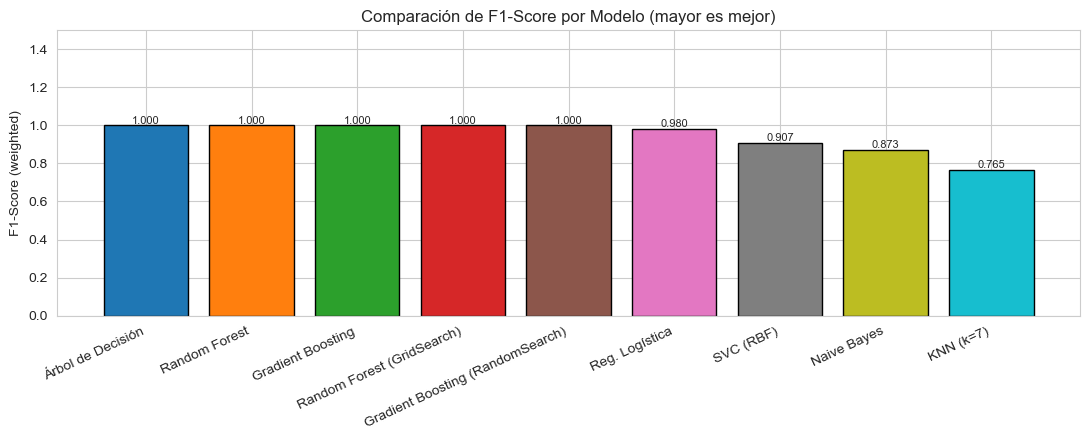

In [23]:
# ── Celda 6b: Gráfico de barras comparativo de F1-Score ─────────────────
orden_barras = df_res.sort_values('F1', ascending=False)
nombres = orden_barras.index.tolist()
f1_val = orden_barras['F1'].tolist()
colores = plt.cm.tab10(np.linspace(0, 1, len(nombres)))
plt.figure(figsize=(11, 4.5))
bars = plt.bar(nombres, f1_val, edgecolor='black', color=colores)
plt.ylabel('F1-Score (weighted)'); plt.ylim(0, 1.5)
plt.title('Comparación de F1-Score por Modelo (mayor es mejor)')
for bar, val in zip(bars, f1_val):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=8)
plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.savefig('comparacion_f1.png', dpi=120, bbox_inches='tight'); plt.show()

Reporte de clasificación — Árbol de Decisión:
              precision    recall  f1-score   support

        Baja       1.00      1.00      1.00        99
       Media       1.00      1.00      1.00        99
        Alta       1.00      1.00      1.00       102

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



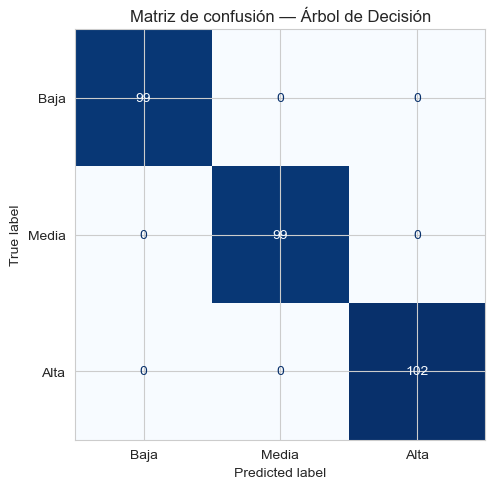

In [24]:
# ── Celda 6c: Matriz de confusión del mejor modelo ──────────────────────
modelo_top = modelos_fit[mejor]
pred_top = modelo_top.predict(X_test)
print(f'Reporte de clasificación — {mejor}:')
print(classification_report(y_test, pred_top, target_names=clases))

cm = confusion_matrix(y_test, pred_top)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm, display_labels=clases).plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f'Matriz de confusión — {mejor}')
plt.tight_layout(); plt.savefig('matriz_confusion_mejor.png', dpi=120, bbox_inches='tight'); plt.show()

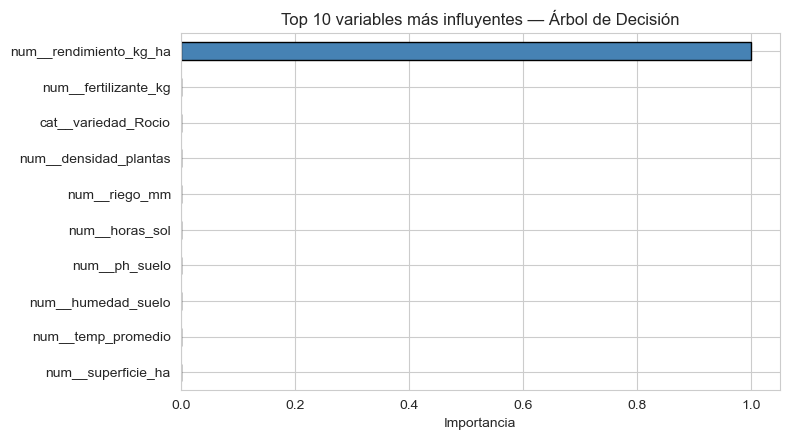

In [25]:
# ── Celda 6d: Importancia de variables del mejor modelo (si aplica) ─────
clf_top = modelo_top.named_steps['clf']
if hasattr(clf_top, 'feature_importances_'):
    nombres_feat = modelo_top.named_steps['pre'].get_feature_names_out()
    imp = (pd.Series(clf_top.feature_importances_, index=nombres_feat)
           .sort_values(ascending=False).head(10))
    plt.figure(figsize=(8, 4.5))
    imp.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
    plt.title(f'Top 10 variables más influyentes — {mejor}')
    plt.xlabel('Importancia')
    plt.tight_layout(); plt.savefig('importancia_variables.png', dpi=120, bbox_inches='tight'); plt.show()
else:
    print(f'El modelo "{mejor}" no expone feature_importances_ '
          '(p. ej. KNN, SVC o Naive Bayes). Use un modelo de árbol para esta vista.')

### Observaciones sobre la comparación y selección de modelos

- Los modelos basados en árboles (Árbol de Decisión, Random Forest y Gradient Boosting) obtuvieron el mejor F1-Score, prácticamente perfecto (F1 ≈ 1.000 en test y ≈ 0.999 en validación cruzada). Se reporta el Árbol de Decisión como modelo destacado por ser el más simple e interpretable con ese desempeño.
- Muy por detrás quedaron la Regresión Logística (F1 ≈ 0.98), SVC (≈ 0.91), Naive Bayes (≈ 0.87) y KNN (≈ 0.77).
- Por qué ganan los árboles: la calidad de cosecha se define, por construcción, a partir de umbrales sobre el rendimiento (y del pH y humedad en rango). Los árboles aprenden justamente reglas de corte (si rendimiento > X entonces Alta), así que reproducen esa lógica casi a la perfección; la importancia de variables muestra que rendimiento_kg_ha concentra casi toda la información.
- Los modelos lineales o de distancia (LogReg, SVC, KNN) no capturan esos cortes netos con la misma limpieza.
- Ajuste de hiperparámetros: el GridSearch (Random Forest) y el RandomizedSearch (Gradient Boosting) no mejoraron de forma significativa al modelo base, porque este ya estaba en el techo de desempeño (F1_CV ≈ 0.999); las versiones optimizadas quedaron en ≈ 0.998, diferencia dentro del margen de ruido. La optimización habría sido más útil si los modelos base hubieran estado lejos del óptimo.
- Clase más difícil: en el mejor modelo la matriz de confusión es perfecta (sin errores). En los modelos más débiles, la clase más confundida es la Media, por ser la categoría intermedia entre Baja y Alta (fronteras difusas).

## 7. Conclusiones e Interpretación de Negocio

- Se selecciona un modelo basado en árboles (en concreto el Árbol de Decisión, y de forma equivalente Random Forest o Gradient Boosting), que alcanzó un F1-Score ≈ 1.000 en prueba y ≈ 0.999 en validación cruzada, con desempeño homogéneo entre las tres clases.
- Se prioriza el Árbol de Decisión por ser el más simple, interpretable y de menor costo de cómputo para igual desempeño; si se buscara mayor robustez ante ruido en producción, Random Forest sería la alternativa natural.
- La calidad depende casi por completo del rendimiento_kg_ha, que concentra prácticamente toda la importancia del modelo. El pH y la humedad, aunque en el EDA mostraban capacidad de separar las clases, quedan en un segundo plano una vez que el modelo dispone del rendimiento: con esa sola variable le basta para clasificar.
- Para AndinaSense el clasificador permite anticipar la calidad de cada parcela a partir de sus sensores y del rendimiento estimado (que puede provenir del modelo del Informe 3). Con ello puede detectar tempranamente las parcelas en riesgo de calidad Baja e intervenir (ajuste de pH, riego o fertilización) antes de la cosecha, y priorizar la logística y comercialización de las parcelas de calidad Alta.
- Conviene vigilar especialmente el recall de la clase Baja para no dejar pasar parcelas problemáticas.

## 8. Anexo de Prompts
Nota: los prompts de generación del dataset sintético (compartido por los Informes 3 a 6) se documentan en el anexo consolidado del proyecto.

| N° | Objetivo | Herramienta | Texto del prompt | Resultado / uso | Validación del equipo |
|----|----------|-------------|------------------|-----------------|-----------------------|
| P-04.1 | Elegir la métrica adecuada para clasificación multiclase y evaluar de forma ordenada | Claude Sonnet 4.5 | *"Tengo un problema de 3 clases y quiero justificar la métrica antes de comparar modelos: explícame cuándo el accuracy es engañoso y por qué el F1-Score weighted se mantiene informativo si el balance cambia. Además necesito una función reutilizable que entrene un Pipeline, evalúe en test y registre Accuracy, Precision, Recall y F1 en una tabla comparativa ordenada, para que todos los modelos se midan igual."* | Se adoptó f1_score(average='weighted') como métrica principal (Celda 4a) y se implementó la función evaluar() usada por todos los modelos, con la tabla final ordenada por F1 | Comprobé que, al estar las clases balanceadas, accuracy y F1 coincidían, y que la tabla ordenada por F1 concordaba con la validación cruzada |
| P-04.2 | Ajustar hiperparámetros sobre pipelines con validación estratificada | Claude Sonnet 4.5 | *"Quiero optimizar dos modelos de ensamble con GridSearchCV y RandomizedSearchCV aplicados sobre un Pipeline, usando la sintaxis clf__ para los parámetros y StratifiedKFold para respetar el balance de clases en cada fold. Explícame cuándo conviene cada búsqueda y qué esperar si el modelo base ya está cerca del techo de desempeño."* | Se aplicó GridSearch a Random Forest y RandomizedSearch a Gradient Boosting (Celdas 5b-5c); la mejora fue marginal porque el modelo base ya rozaba F1 ≈ 0.999 | Observé que las versiones optimizadas quedaron en ≈ 0.998, dentro del margen de ruido, lo que confirmó que la optimización aporta poco cuando el base ya está en el óptimo |
| P-04.3 | Interpretar un desempeño casi perfecto y reconocerlo como limitación | Claude Sonnet 4.5 | *"Mi clasificador da F1 ≈ 1.0 y la importancia de variables recae casi por completo en rendimiento_kg_ha, que es una variable derivada del mismo proceso que define la etiqueta de calidad. Quiero saber si esto constituye una fuga de información por diseño del target y cómo plantearlo con honestidad como limitación del informe, en lugar de presentarlo como un logro."* | Se documentó como limitación la casi-fuga por el uso de rendimiento_kg_ha, señalando que en un escenario real donde el rendimiento no se conoce al predecir el problema sería más difícil | Confirmé la explicación revisando la importancia de variables y la definición del target, y añadí la recomendación de reentrenar solo con variables de sensor |
| P-04.4 | Diagnosticar errores y advertencias durante el modelado multiclase | Claude Opus 4.8 | *"Durante el modelado aparecieron varias incidencias que quiero resolver bien: un ConvergenceWarning en la Regresión Logística multinomial, un ValueError por usar average='binary' en un problema multiclase, y un AttributeError al graficar feature_importances_ en modelos que no la exponen. Explícame la causa de cada una y cómo corregirlas sin alterar los resultados."* | Se subió max_iter en la Regresión Logística manteniendo el escalado en el Pipeline, se usó average='weighted' en las métricas, y se agregó hasattr(modelo, 'feature_importances_') antes de graficar | Verifiqué que las métricas no cambiaran tras subir max_iter, que los valores coincidieran con el classification_report y que la celda de importancia funcionara tanto para árboles como para modelos lineales |